Movies Shape: (9742, 3)
Ratings Shape: (100836, 4)

Movies Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Ratings Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Movies Sample
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Ju

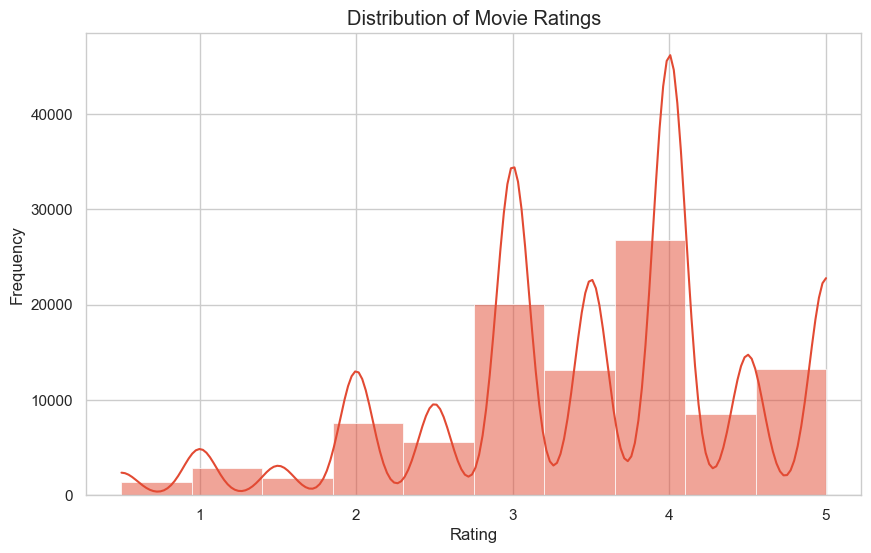

Box Plot


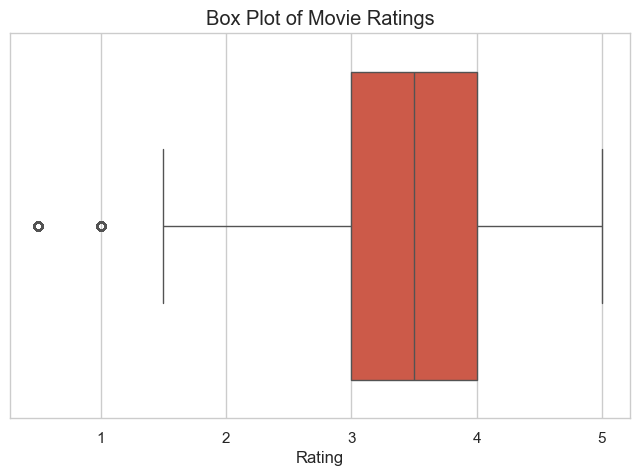

Top Rated Movies

Top Rated Movies
                                                  title  average_rating  \
7593                   Shawshank Redemption, The (1994)        4.429022   
3499                              Godfather, The (1972)        4.289062   
3011                                  Fight Club (1999)        4.272936   
1961                              Cool Hand Luke (1967)        4.271930   
2531  Dr. Strangelove or: How I Learned to Stop Worr...        4.268041   
6999                                 Rear Window (1954)        4.261905   
3500                     Godfather: Part II, The (1974)        4.259690   
2334                               Departed, The (2006)        4.252336   
3564                                  Goodfellas (1990)        4.250000   
1593                                  Casablanca (1942)        4.240000   

      total_ratings  
7593            317  
3499            192  
3011            218  
1961             57  
2531             97  
6999   

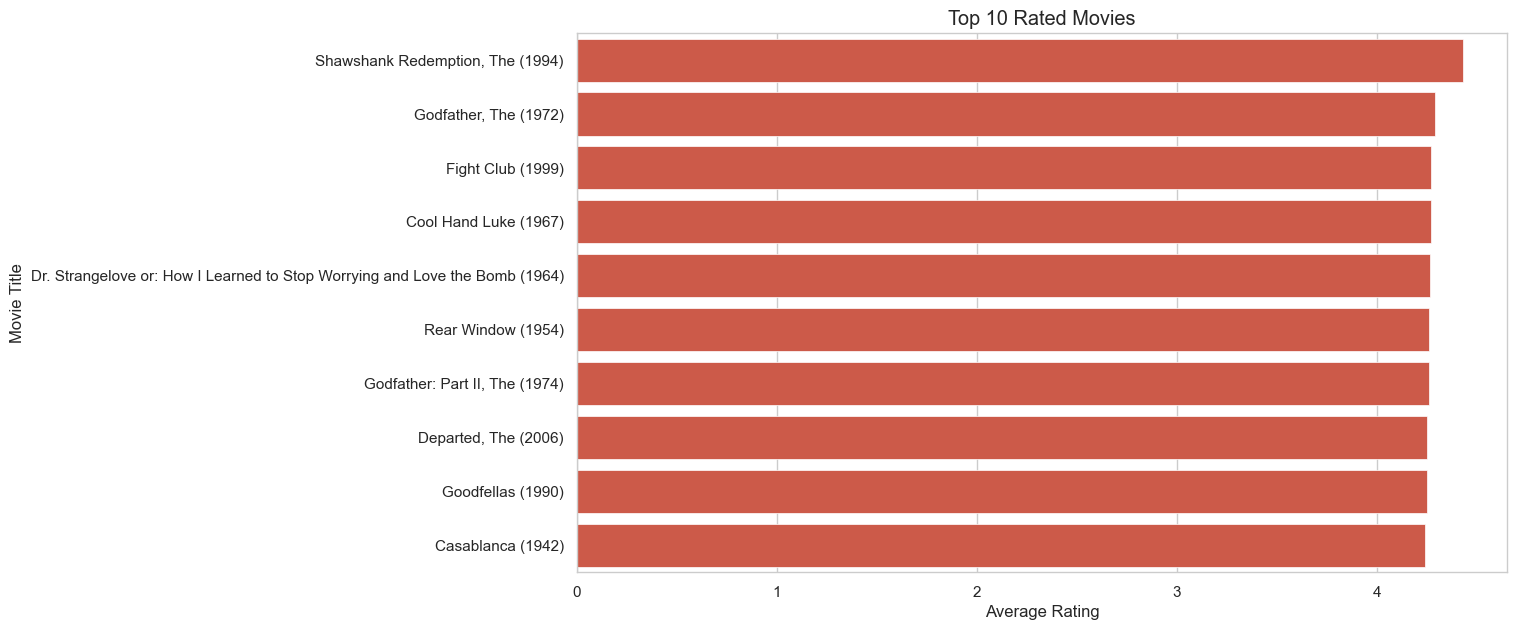

Genre Analysis

Top Rated Genres
         genres  average_rating  total_ratings
10    Film-Noir        3.920115            870
18          War        3.808294           4859
7   Documentary        3.797785           1219
6         Crime        3.658294          16681
8         Drama        3.656184          41928
14      Mystery        3.632460           7674
3     Animation        3.629937           6988
12         IMAX        3.618335           4145
19      Western        3.583938           1930
13      Musical        3.563678           4138


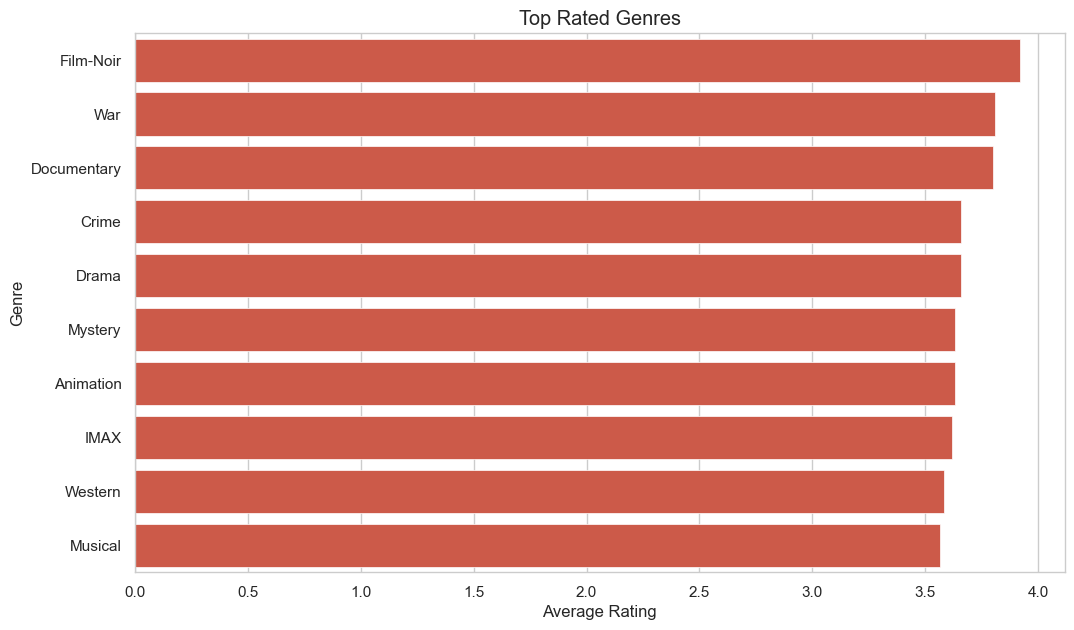

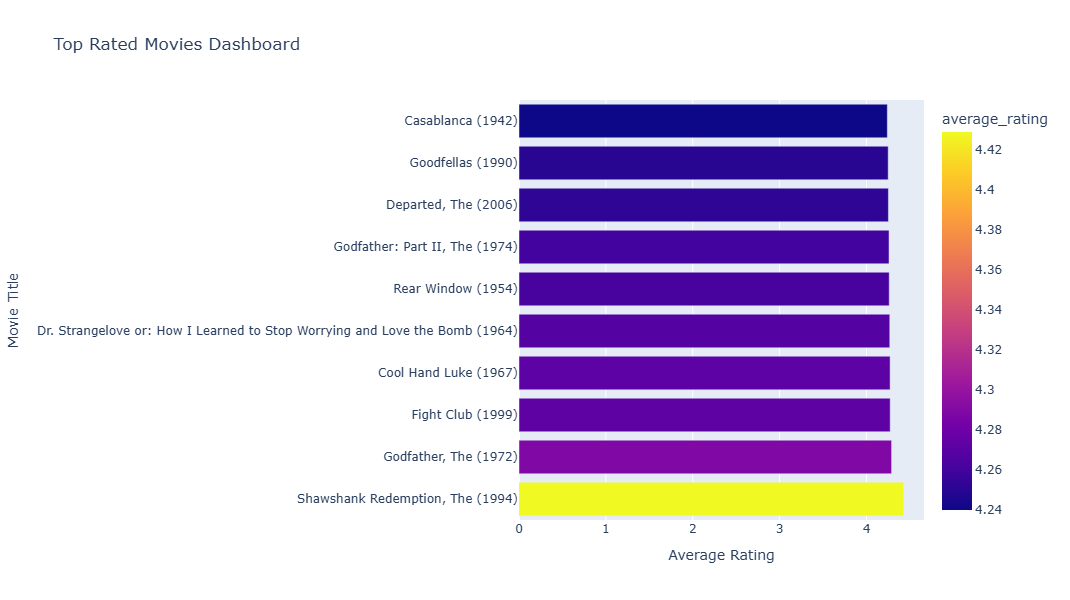


Dashboard saved successfully!

Movie Ratings Analysis Completed Successfully.


In [11]:
# ==========================================
# Project: Movie Ratings Analysis Dashboard
# ==========================================

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Create folders

os.makedirs("images", exist_ok=True)
os.makedirs("dashboard", exist_ok=True)

# Plot settings

plt.style.use("ggplot")
sns.set_style("whitegrid")

# ==========================================
# Load Dataset
# ==========================================

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# ==========================================
# Explore Dataset
# ==========================================

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

print("\nMovies Information")
print(movies.info())

print("\nRatings Information")
print(ratings.info())

print("\nMovies Sample")
print(movies.head())

print("\nRatings Sample")
print(ratings.head())

# ==========================================
print("Missing Values Check")
# ==========================================

print("\nMissing Values")

print(movies.isnull().sum())
print(ratings.isnull().sum())

# ==========================================
# Data Cleaning
# ==========================================

movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

# Convert timestamp

ratings["timestamp"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

# Merge datasets

movie_data = pd.merge(
    ratings,
    movies,
    on="movieId",
    how="inner"
)

# Extract release year

movie_data["year"] = movie_data["title"].str.extract(r"\((\d{4})\)")

# Remove rows with missing ratings

movie_data = movie_data.dropna(subset=["rating"])

# ==========================================
#Summary Statistics
# ==========================================

mean_rating = movie_data["rating"].mean()
median_rating = movie_data["rating"].median()
mode_rating = movie_data["rating"].mode()[0]

print("\nSummary Statistics")

print(f"Mean Rating   : {mean_rating:.2f}")
print(f"Median Rating : {median_rating:.2f}")
print(f"Mode Rating   : {mode_rating}")

# ==========================================
print("Histogram")
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    movie_data["rating"],
    bins=10,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig(
    "images/ratings_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
print("Box Plot")
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=movie_data["rating"]
)

plt.title("Box Plot of Movie Ratings")
plt.xlabel("Rating")

plt.savefig(
    "images/ratings_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
print("Top Rated Movies")
# ==========================================

movie_stats = movie_data.groupby("title").agg(
    average_rating=("rating", "mean"),
    total_ratings=("rating", "count")
).reset_index()

top_movies = movie_stats[
    movie_stats["total_ratings"] >= 50
]

top_movies = top_movies.sort_values(
    by="average_rating",
    ascending=False
).head(10)

print("\nTop Rated Movies")

print(top_movies)

# ==========================================
print("Top Movies Visualization")
# ==========================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_movies,
    x="average_rating",
    y="title"
)

plt.title("Top 10 Rated Movies")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.savefig(
    "images/top_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
print("Genre Analysis")
# ==========================================

movie_data["genres"] = movie_data["genres"].str.split("|")

genre_data = movie_data.explode("genres")

genre_stats = genre_data.groupby("genres").agg(
    average_rating=("rating", "mean"),
    total_ratings=("rating", "count")
).reset_index()

genre_stats = genre_stats[
    genre_stats["total_ratings"] >= 100
]

top_genres = genre_stats.sort_values(
    by="average_rating",
    ascending=False
).head(10)

print("\nTop Rated Genres")

print(top_genres)

# ==========================================
#Genre Visualization
# ==========================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_genres,
    x="average_rating",
    y="genres"
)

plt.title("Top Rated Genres")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.savefig(
    "images/top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# Interactive Dashboard
# ==========================================

dashboard = px.bar(
    top_movies,
    x="average_rating",
    y="title",
    orientation="h",
    color="average_rating",
    title="Top Rated Movies Dashboard"
)

dashboard.update_layout(
    xaxis_title="Average Rating",
    yaxis_title="Movie Title",
    height=600
)

dashboard.write_html(
    "dashboard/movie_dashboard.html"
)

dashboard.show()

print("\nDashboard saved successfully!")

# ==========================================
# Project Completed
# ==========================================

print("\nMovie Ratings Analysis Completed Successfully.")